# Impact of Bad Rows on TabPFN Performance

**Goal**: Investigate how rows with anomalous sale-price-to-assessed-value ratios
affect TabPFN prediction quality on Cook County data.

**Design**:
1. Load Cook County data, compute `MARKET_TOTAL_VALUE / exp(SALE_AMOUNT)` ratio
2. Explore the distribution of ratios to identify "bad" rows
3. Temporal 80/20 train/test split
4. Remove bad rows from test set (so evaluation is always on clean data)
5. **Run A**: Train TabPFN on full train set (with bad rows) -> evaluate on clean test
6. **Run B**: Train TabPFN on cleaned train set (bad rows removed) -> evaluate on same clean test
7. Compare metrics

In [1]:
import sys
sys.path.insert(0, '../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.loading import CleanedDataLoader
from src.evaluation.metrics import compute_metrics

## 1. Load Cook County Data

In [2]:
DATA_PATH = "/nlp/scr/salilg/showcase_property_tax/preprocessed/v2_no_onehot/"
COOK_FIPS = 17031

loader = CleanedDataLoader(cleaned_data_path=DATA_PATH)

# Load just fips column to find Cook County row indices
fips_arr = loader.load_fips_column()
cook_indices = np.where(fips_arr == COOK_FIPS)[0]
print(f"Cook County rows: {len(cook_indices):,}")

# Load Cook County data
df_cook = loader.load_data_by_indices(cook_indices)
print(f"Shape: {df_cook.shape}")
df_cook.head()

Cook County rows: 204,464
Shape: (204464, 123)


,Unnamed: 0,ASSESSED_YEAR,CENSUS_ID,fips,MARKET_TOTAL_VALUE,latitude,longitude,address,TAX_YEAR,TOTAL_TAX_AMOUNT,...,census_med_yr_built_bg,census_pct_renter_occ_bg,census_med_rent_bg,block_group_id,sale_year,sale_month,sale_day_of_month,sale_day_of_year,sale_day_of_week,sale_day
0,12390,2018,8.107011e+09,17031,188650.0,41.933900,-87.812359,2937 N 74TH CT,2018.0,5009.71,...,1956.0,0.465517,1221.0,1.703181e+11,2018,11,9,313,4,6887
1,12391,2019,8.041041e+09,17031,409170.0,42.102207,-88.102472,4325 EISENHOWER CIR,2019.0,2190.13,...,1975.0,0.795041,3272.0,1.703180e+11,2019,4,24,114,2,7053
2,12392,2019,8.300051e+09,17031,184320.0,41.511599,-87.711221,800 CUMNOCK RD,2019.0,9659.05,...,1985.0,0.762168,3448.0,1.703183e+11,2019,4,16,106,1,7045
3,12393,2018,6.108001e+09,17031,200170.0,41.811101,-87.637652,444 W 46TH ST,2018.0,3954.00,...,NaN,0.720395,1329.0,1.703161e+11,2018,5,2,122,2,6696
4,12394,2018,8.207001e+09,17031,95370.0,41.820340,-87.788452,3927 CLARENCE AVE,2018.0,2550.66,...,1955.0,1.000000,NaN,1.703182e+11,2018,1,12,12,4,6586


## 2. Explore Sale Price vs Assessed Value Ratio

In [3]:
# SALE_AMOUNT is log-transformed, so exp() to get dollar amounts
df_cook['sale_price_dollars'] = np.exp(df_cook['SALE_AMOUNT'])
df_cook['ratio'] = df_cook['MARKET_TOTAL_VALUE'] / df_cook['sale_price_dollars']

print("Ratio stats (MARKET_TOTAL_VALUE / sale_price):")
print(df_cook['ratio'].describe())
print(f"\nNaN ratios: {df_cook['ratio'].isna().sum()}")
print(f"Inf ratios: {np.isinf(df_cook['ratio']).sum()}")
print(f"Zero sale price: {(df_cook['sale_price_dollars'] == 0).sum()}")

Ratio stats (MARKET_TOTAL_VALUE / sale_price):
count    204464.000000
mean          0.847141
std           0.332073
min           0.017048
25%           0.664117
50%           0.815850
75%           0.976067
max           3.049048
Name: ratio, dtype: float64

NaN ratios: 0
Inf ratios: 0
Zero sale price: 0


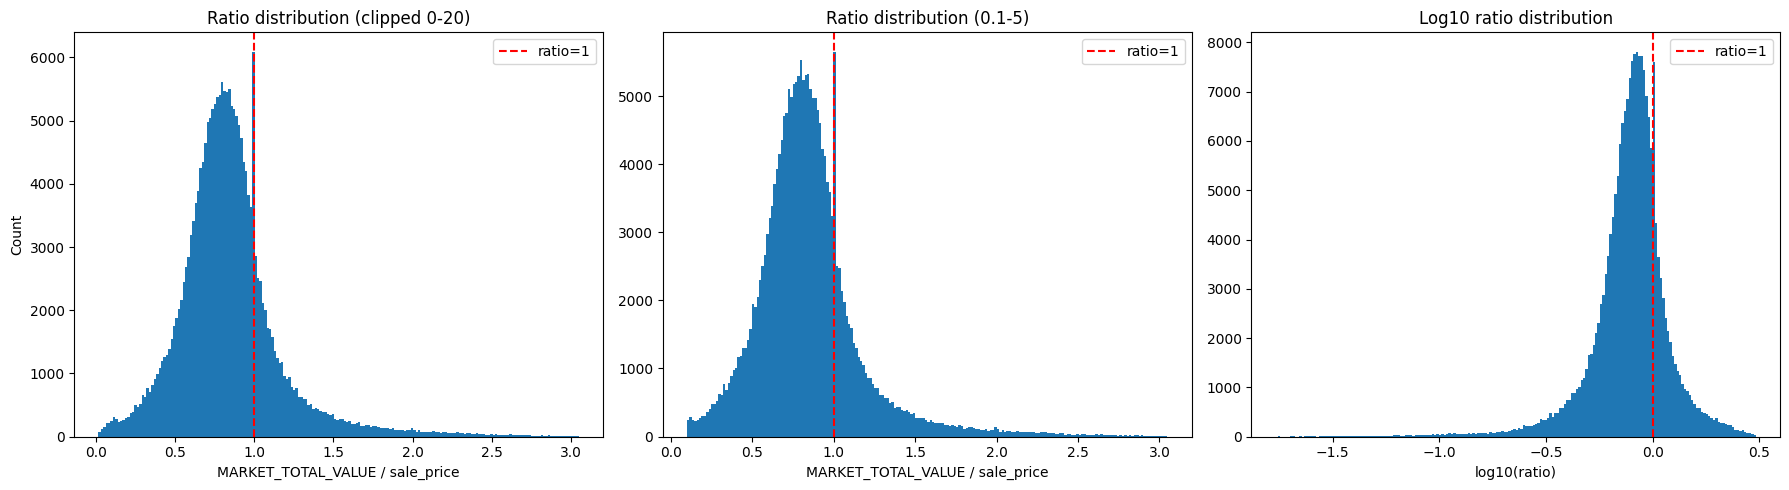

In [4]:
# Distribution of the ratio
valid_ratio = df_cook['ratio'].replace([np.inf, -np.inf], np.nan).dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Full distribution (clipped for visibility)
axes[0].hist(valid_ratio.clip(0, 20), bins=200, edgecolor='none')
axes[0].set_xlabel('MARKET_TOTAL_VALUE / sale_price')
axes[0].set_ylabel('Count')
axes[0].set_title('Ratio distribution (clipped 0-20)')
axes[0].axvline(x=1.0, color='red', linestyle='--', label='ratio=1')
axes[0].legend()

# Zoomed in around 1
axes[1].hist(valid_ratio[(valid_ratio > 0.1) & (valid_ratio < 5)], bins=200, edgecolor='none')
axes[1].set_xlabel('MARKET_TOTAL_VALUE / sale_price')
axes[1].set_title('Ratio distribution (0.1-5)')
axes[1].axvline(x=1.0, color='red', linestyle='--', label='ratio=1')
axes[1].legend()

# Log scale
axes[2].hist(np.log10(valid_ratio[valid_ratio > 0]), bins=200, edgecolor='none')
axes[2].set_xlabel('log10(ratio)')
axes[2].set_title('Log10 ratio distribution')
axes[2].axvline(x=0.0, color='red', linestyle='--', label='ratio=1')
axes[2].legend()

plt.tight_layout()
plt.show()

In [7]:
# Percentile breakdown
percentiles = [0.5, 1, 2, 5, 10, 25, 50, 75, 90, 95, 98, 99, 99.5]
print("Ratio percentiles:")
for p in percentiles:
    val = np.nanpercentile(valid_ratio, p)
    print(f"  {p:5.1f}%ile: {val:.4f}")

Ratio percentiles:
    0.5%ile: 0.1081
    1.0%ile: 0.1667
    2.0%ile: 0.2564
    5.0%ile: 0.3895
   10.0%ile: 0.5046
   25.0%ile: 0.6641
   50.0%ile: 0.8158
   75.0%ile: 0.9761
   90.0%ile: 1.1844
   95.0%ile: 1.4241
   98.0%ile: 1.8168
   99.0%ile: 2.1189
   99.5%ile: 2.3567


In [8]:
# Look at the worst offenders on both ends
print("=== Lowest ratios (assessed << sale price, possibly non-arm's-length) ===")
low_ratio = df_cook.nsmallest(10, 'ratio')[['SALE_AMOUNT', 'sale_price_dollars', 'MARKET_TOTAL_VALUE', 'ratio']]
print(low_ratio.to_string())

print("\n=== Highest ratios (assessed >> sale price, possibly fire sales / $1 transfers) ===")
high_ratio = df_cook.nlargest(10, 'ratio')[['SALE_AMOUNT', 'sale_price_dollars', 'MARKET_TOTAL_VALUE', 'ratio']]
print(high_ratio.to_string())

=== Lowest ratios (assessed << sale price, possibly non-arm's-length) ===
        SALE_AMOUNT  sale_price_dollars  MARKET_TOTAL_VALUE     ratio
202775    14.780591           2625000.0             44750.0  0.017048
179543    13.891545           1079000.0             19050.0  0.017655
179195    14.077875           1300000.0             23170.0  0.017823
176658    15.232577           4125000.0             76690.0  0.018592
192215    13.208541            545000.0             10800.0  0.019817
182689    15.075391           3525000.0             70720.0  0.020062
52540     15.068274           3500000.0             70580.0  0.020166
172478    15.075391           3525000.0             73940.0  0.020976
185219    15.075391           3525000.0             73940.0  0.020976
183220    14.070153           1290000.0             27684.0  0.021460

=== Highest ratios (assessed >> sale price, possibly fire sales / $1 transfers) ===
        SALE_AMOUNT  sale_price_dollars  MARKET_TOTAL_VALUE     ratio
8

In [9]:
# Count bad rows at various thresholds
print("Bad row counts at various ratio thresholds:")
print(f"{'Threshold':<30} {'Count':>8} {'Pct':>8}")
print("-" * 50)

n_total = len(valid_ratio)
thresholds = [
    ('ratio < 0.1', valid_ratio < 0.1),
    ('ratio < 0.2', valid_ratio < 0.2),
    ('ratio < 0.5', valid_ratio < 0.5),
    ('ratio > 2', valid_ratio > 2),
    ('ratio > 5', valid_ratio > 5),
    ('ratio > 10', valid_ratio > 10),
    ('ratio > 50', valid_ratio > 50),
    ('ratio < 0.1 OR ratio > 10', (valid_ratio < 0.1) | (valid_ratio > 10)),
    ('ratio < 0.2 OR ratio > 5', (valid_ratio < 0.2) | (valid_ratio > 5)),
    ('Bottom/top 1%ile', True),  # placeholder
    ('Bottom/top 5%ile', True),  # placeholder
]

for label, mask in thresholds:
    if 'Bottom/top 1%' in label:
        p1, p99 = np.nanpercentile(valid_ratio, [1, 99])
        mask = (valid_ratio < p1) | (valid_ratio > p99)
    elif 'Bottom/top 5%' in label:
        p5, p95 = np.nanpercentile(valid_ratio, [5, 95])
        mask = (valid_ratio < p5) | (valid_ratio > p95)
    count = mask.sum()
    print(f"{label:<30} {count:>8,} {count/n_total*100:>7.2f}%")

Bad row counts at various ratio thresholds:
Threshold                         Count      Pct
--------------------------------------------------
ratio < 0.1                         900    0.44%
ratio < 0.2                       2,658    1.30%
ratio < 0.5                      19,899    9.73%
ratio > 2                         2,707    1.32%
ratio > 5                             0    0.00%
ratio > 10                            0    0.00%
ratio > 50                            0    0.00%
ratio < 0.1 OR ratio > 10           900    0.44%
ratio < 0.2 OR ratio > 5          2,658    1.30%
Bottom/top 1%ile                  4,089    2.00%
Bottom/top 5%ile                 20,448   10.00%


## 3. Define Bad Rows & Prepare Train/Test Split

Based on the exploration above, choose a threshold. We'll try a few.

In [ ]:
# Temporal split: oldest 80% train, newest 20% test
# Using sale_day (days since 2000-01-01) for temporal ordering
temporal_col = 'sale_day'
cutoff = df_cook[temporal_col].quantile(0.8)

train_mask = df_cook[temporal_col] <= cutoff
test_mask = df_cook[temporal_col] > cutoff

print(f"Train: {train_mask.sum():,} rows")
print(f"Test:  {test_mask.sum():,} rows")
print(f"Temporal cutoff (sale_day): {cutoff}")

In [ ]:
# Columns to exclude from features (matching the project's conventions)
EXCLUDE_COLS = {
    'fips', 'CLIP', 'sale_date', 'Unnamed: 0', 'ASSESSED_YEAR', 'CENSUS_ID',
    'PREVIOUS_CLIP', 'OWNER_TRANSFER_COMPOSITE_TRANSACTION_ID', 'address',
    'TOTAL_TAX_AMOUNT', 'NET_TAX_AMOUNT', 'TAX_RATE_AREA_CODE',
    'CALCULATED_TOTAL_VALUE_SOURCE_CODE', 'tract', 'block_group',
    'tract_id', 'block_group_id', 'MULTI_OR_SPLIT_PARCEL_CODE', 'meta_sfh',
    'CALCULATED_TOTAL_VALUE',
    # Also exclude our computed columns
    'sale_price_dollars', 'ratio',
    # Target
    'SALE_AMOUNT',
}

feature_cols = [c for c in df_cook.columns if c not in EXCLUDE_COLS]
print(f"Feature columns: {len(feature_cols)}")
print(feature_cols)

In [ ]:
def define_bad_rows(df, bottom_pct=5, top_pct=95):
    """Flag bad rows based on ratio percentiles."""
    ratio = df['ratio'].replace([np.inf, -np.inf], np.nan)
    lo = np.nanpercentile(ratio, bottom_pct)
    hi = np.nanpercentile(ratio, top_pct)
    is_bad = (ratio < lo) | (ratio > hi) | ratio.isna()
    return is_bad, lo, hi


def prepare_splits(df, train_mask, test_mask, feature_cols, bad_mask):
    """Prepare clean test set and two training variants."""
    target = 'SALE_AMOUNT'
    
    # Clean test set (always remove bad rows from test)
    test_clean_mask = test_mask & ~bad_mask
    X_test = df.loc[test_clean_mask, feature_cols].reset_index(drop=True)
    y_test = df.loc[test_clean_mask, target].reset_index(drop=True)
    
    # Training set A: full (including bad rows)
    X_train_full = df.loc[train_mask, feature_cols].reset_index(drop=True)
    y_train_full = df.loc[train_mask, target].reset_index(drop=True)
    
    # Training set B: cleaned (bad rows removed)
    train_clean_mask = train_mask & ~bad_mask
    X_train_clean = df.loc[train_clean_mask, feature_cols].reset_index(drop=True)
    y_train_clean = df.loc[train_clean_mask, target].reset_index(drop=True)
    
    return {
        'X_test': X_test, 'y_test': y_test,
        'X_train_full': X_train_full, 'y_train_full': y_train_full,
        'X_train_clean': X_train_clean, 'y_train_clean': y_train_clean,
    }

## 4. Run TabPFN: Full Train vs Cleaned Train

We cap training size at 10K (TabPFN's context limit) by random sampling.

In [ ]:
from src.models.tabpfn_wrapper import TabPFNModel

TABPFN_MAX_CONTEXT = 10000
SEED = 42


def subsample_train(X, y, max_n=TABPFN_MAX_CONTEXT, seed=SEED):
    """Subsample training data if it exceeds TabPFN's context limit."""
    if len(X) <= max_n:
        return X, y
    rng = np.random.RandomState(seed)
    idx = rng.choice(len(X), size=max_n, replace=False)
    return X.iloc[idx].reset_index(drop=True), y.iloc[idx].reset_index(drop=True)


def run_tabpfn(X_train, y_train, X_test, y_test, label=""):
    """Train TabPFN and evaluate. Returns metrics dict."""
    X_tr, y_tr = subsample_train(X_train, y_train)
    print(f"\n[{label}] Training on {len(X_tr):,} samples, evaluating on {len(X_test):,} samples")
    
    model = TabPFNModel(device='cuda', version='v2', random_state=SEED)
    model.fit(X_tr, y_tr)
    preds = model.predict(X_test)
    
    # compute_metrics with log_transformed=True to get dollar-scale metrics
    metrics = compute_metrics(y_test.values, preds, log_transformed=True)
    print(f"  R2:   {metrics['r2']:.4f}")
    print(f"  RMSE: {metrics['rmse']:,.0f}")
    print(f"  MAE:  {metrics['mae']:,.0f}")
    print(f"  MAPE: {metrics['mape']:.2f}%")
    
    model.cleanup()
    return metrics

In [ ]:
# Run the comparison at the default threshold (bottom/top 5%)
bad_mask, lo, hi = define_bad_rows(df_cook, bottom_pct=5, top_pct=95)
print(f"Bad rows: {bad_mask.sum():,} / {len(df_cook):,} ({bad_mask.sum()/len(df_cook)*100:.1f}%)")
print(f"Ratio thresholds: [{lo:.4f}, {hi:.4f}]")

splits = prepare_splits(df_cook, train_mask, test_mask, feature_cols, bad_mask)
print(f"\nTrain full:  {len(splits['X_train_full']):,}")
print(f"Train clean: {len(splits['X_train_clean']):,}")
print(f"Test clean:  {len(splits['X_test']):,}")
print(f"Bad rows removed from train: {len(splits['X_train_full']) - len(splits['X_train_clean']):,}")

In [ ]:
# Run A: Full training set (with bad rows)
metrics_full = run_tabpfn(
    splits['X_train_full'], splits['y_train_full'],
    splits['X_test'], splits['y_test'],
    label="Full train (with bad rows)"
)

In [ ]:
# Run B: Cleaned training set (bad rows removed)
metrics_clean = run_tabpfn(
    splits['X_train_clean'], splits['y_train_clean'],
    splits['X_test'], splits['y_test'],
    label="Cleaned train (bad rows removed)"
)

## 5. Compare Results

In [ ]:
# Side-by-side comparison
comparison = pd.DataFrame({
    'Full Train': metrics_full,
    'Cleaned Train': metrics_clean,
}).T

comparison['r2_delta'] = comparison['r2'] - comparison['r2'].iloc[0]
comparison['rmse_delta'] = comparison['rmse'] - comparison['rmse'].iloc[0]
comparison['mae_delta'] = comparison['mae'] - comparison['mae'].iloc[0]

print("=" * 80)
print("COMPARISON: Full Train vs Cleaned Train (evaluated on clean test set)")
print("=" * 80)
print(comparison[['r2', 'rmse', 'mae', 'mape']].to_string(float_format=lambda x: f"{x:.4f}"))
print("\nDeltas (Cleaned - Full):")
print(f"  R2:   {comparison['r2_delta'].iloc[1]:+.4f}")
print(f"  RMSE: {comparison['rmse_delta'].iloc[1]:+,.0f}")
print(f"  MAE:  {comparison['mae_delta'].iloc[1]:+,.0f}")

## 6. Sensitivity: Varying the Badness Threshold

Try different percentile cutoffs to see how aggressively filtering affects performance.

In [ ]:
# Run across multiple thresholds
# Format: (bottom_percentile, top_percentile)
threshold_configs = [
    (0, 100),   # No filtering (baseline) - keeps all rows
    (1, 99),    # Drop bottom/top 1%
    (2, 98),    # Drop bottom/top 2%
    (5, 95),    # Drop bottom/top 5%
    (10, 90),   # Drop bottom/top 10%
    (20, 80),   # Drop bottom/top 20%
]

results = []

for bottom_pct, top_pct in threshold_configs:
    pct_removed = (bottom_pct + (100 - top_pct))
    label = f"Drop {pct_removed}% (p{bottom_pct}-p{top_pct})"
    
    if bottom_pct == 0 and top_pct == 100:
        # No filtering - use full train, but still clean test
        # For "no filter" baseline, only remove NaN/inf ratios from test
        bad_mask_test = df_cook['ratio'].isna() | np.isinf(df_cook['ratio'])
        bad_mask_train = pd.Series(False, index=df_cook.index)  # keep all train rows
        
        test_clean = test_mask & ~bad_mask_test
        X_test = df_cook.loc[test_clean, feature_cols].reset_index(drop=True)
        y_test = df_cook.loc[test_clean, 'SALE_AMOUNT'].reset_index(drop=True)
        X_train = df_cook.loc[train_mask, feature_cols].reset_index(drop=True)
        y_train = df_cook.loc[train_mask, 'SALE_AMOUNT'].reset_index(drop=True)
    else:
        bad_mask, lo, hi = define_bad_rows(df_cook, bottom_pct=bottom_pct, top_pct=top_pct)
        splits = prepare_splits(df_cook, train_mask, test_mask, feature_cols, bad_mask)
        X_train, y_train = splits['X_train_clean'], splits['y_train_clean']
        X_test, y_test = splits['X_test'], splits['y_test']
    
    metrics = run_tabpfn(X_train, y_train, X_test, y_test, label=label)
    metrics['threshold'] = label
    metrics['bottom_pct'] = bottom_pct
    metrics['top_pct'] = top_pct
    metrics['pct_removed'] = pct_removed
    metrics['n_train'] = len(X_train)
    metrics['n_test'] = len(X_test)
    results.append(metrics)

results_df = pd.DataFrame(results)
print("\n" + "=" * 80)
print(results_df[['threshold', 'n_train', 'n_test', 'r2', 'rmse', 'mae', 'mape']].to_string(index=False))

In [ ]:
# Plot sensitivity curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x = results_df['pct_removed']

axes[0].plot(x, results_df['r2'], 'o-', markersize=8)
axes[0].set_xlabel('% of data removed (symmetric)')
axes[0].set_ylabel('R2')
axes[0].set_title('R2 vs Filtering Aggressiveness')
axes[0].grid(True, alpha=0.3)

axes[1].plot(x, results_df['rmse'], 'o-', markersize=8, color='orange')
axes[1].set_xlabel('% of data removed (symmetric)')
axes[1].set_ylabel('RMSE ($)')
axes[1].set_title('RMSE vs Filtering Aggressiveness')
axes[1].grid(True, alpha=0.3)

axes[2].plot(x, results_df['mae'], 'o-', markersize=8, color='green')
axes[2].set_xlabel('% of data removed (symmetric)')
axes[2].set_ylabel('MAE ($)')
axes[2].set_title('MAE vs Filtering Aggressiveness')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Summary table
print("\nFull results summary:")
print(results_df[['threshold', 'n_train', 'n_test', 'r2', 'rmse', 'mae', 'mape']].to_string(index=False))